# Habitable Zone Classification — Logistic Regression



### Model Performance Comparison

| Model                              | Threshold | ROC-AUC | PR-AUC | Precision | Recall | F1-score |
|-----------------------------------|----------|--------|--------|-----------|--------|----------|
| Model 1 Baseline Logistic                 | 0.50     | 0.9141 | 0.3133 | 0.2976    | 0.9494 | 0.4532   |
| Model 2 Tuned Logistic                    | 0.50     | 0.9457 | 0.4268 | 0.3423    | 0.9620 | 0.5050   |
| Model 3 Tuned Logistic (Val Threshold)    | 0.72     | 0.9457 | 0.4268 | 0.4340    | 0.8734 | **0.5798** |
| Model 4 SMOTE Logistic                    | 0.50     | 0.9460 | 0.4327 | 0.3519    | 0.9620 | 0.5153   |
| Model 5 SMOTE Logistic (Val Threshold)    | 0.80     | 0.9460 | 0.4327 | **0.4683**| 0.7468 | 0.5756   |

### Interpretation
We start with the baseline logistic regression model(Model 1 L2 Regularization) using a threshold of 0.5.  The ROC-AUC is 0.91, which is reasonable.  However, the PR-AUC is low at 0.31, and precision is poor at 0.30.  Recall is very high at 0.95.  Model 1 predicts the positive class too often, a common issue in imbalanced datasets.

Next, we apply cross-validated hyperparameter tuning to Model 2(L1 c=10). 
The ROC-AUC increases to around 0.95.  The PR-AUC also improves to about 0.43.  This shows that the model is better at ranking observations.  However, at the default threshold of 0.5, recall is still very high (above 0.96).  Precision remains relatively low.  

Given the class imbalance, the threshold becomes critical. We therefore select the threshold using validation data.  

For the Model 3 tuned model , increasing the threshold to 0.72 improves precision .  
Recall decreases slightly but remains high.  

Finally, we evaluate the effect of SMOTE. Model 4 slightly improves PR-AUC and keeps recall very high.  

After threshold tuning, the SMOTE model (Model 5) performs similarly to the tuned model without SMOTE. It does not clearly outperform it. 

Overall, Model 3 provides the most balanced and reliable results. We therefore choose it as the final model.


In [66]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

## 1. Load data

In [67]:
df_cleaned = pd.read_csv("exoplanet_clean.csv")
df = df_cleaned.copy()

print("Shape:", df.shape)
df.head()

Shape: (5451, 21)


,n_stars,n_planets,discovery_method,orbital_period_days,planet_radius_earth,planet_mass_earth,semi_major_axis_au,star_temp_k,star_radius_sun,star_mass_sun,...,star_metallicity,dist_from_earth_pc,star_vmag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,1,1,Transit,1.003934,1.710000,3.570,0.01750,4971.0,0.750,0.790,...,-0.05,820.905,16.0470,Super-Earth,False,False,False,Far(500-2kpc),K-type,Short(1-10d)
1,1,1,Transit,8.172400,3.323214,11.000,0.07790,5705.0,0.905,0.943,...,-0.06,1061.770,15.4540,Mini-Neptune,False,False,True,Far(500-2kpc),G-type(Sun-like),Short(1-10d)
2,1,1,Transit,6.283855,0.800000,0.437,0.06865,6022.0,1.230,1.120,...,0.07,493.175,12.4420,Sub-Earth,False,False,False,Mid(100-500pc),F-type,Short(1-10d)
3,1,1,Transit,3.173917,3.150000,10.100,0.04641,6747.0,1.810,1.490,...,0.08,1318.050,14.0310,Mini-Neptune,False,False,False,Far(500-2kpc),F-type,Short(1-10d)
4,1,1,Transit,56.358501,4.540605,18.700,0.26980,5446.0,0.821,0.824,...,-0.20,962.888,16.0249,Neptune-like,False,False,True,Far(500-2kpc),G-type(Sun-like),Medium(10-100d)


In [68]:
df.dtypes

n_stars                   int64
n_planets                 int64
discovery_method         object
orbital_period_days     float64
planet_radius_earth     float64
planet_mass_earth       float64
semi_major_axis_au      float64
star_temp_k             float64
star_radius_sun         float64
star_mass_sun           float64
star_surface_gravity    float64
star_metallicity        float64
dist_from_earth_pc      float64
star_vmag               float64
planet_type              object
habitable_zone_flag        bool
multi_planet_system        bool
is_recent_discovery        bool
dist_category            object
star_type                object
orbital_period_cat       object
dtype: object

## 2. Feature engineering
Note: `stellar_flux` is treated as a simplified proxy rather than a fully physical luminosity model.

In [69]:
# Simplified stellar flux proxy
df["stellar_flux"] = (df["star_temp_k"] ** 4) / (df["semi_major_axis_au"] ** 2)

# Log transformations
df["log_semi_major_axis"] = np.log(df["semi_major_axis_au"] + 1e-6)
df["log_star_temp"] = np.log(df["star_temp_k"])

# Interaction term
df["temp_distance_interaction"] = df["star_temp_k"] * df["semi_major_axis_au"]

# Binary flags
df["habitable_zone_flag"] = df["habitable_zone_flag"].astype(int)
df["multi_planet_system"] = df["multi_planet_system"].astype(int)

In [70]:
features = [
    "semi_major_axis_au",
    "orbital_period_days",
    "star_temp_k",
    "star_radius_sun",
    "star_mass_sun",
    "star_metallicity",
    "planet_mass_earth",
    "multi_planet_system",
    "stellar_flux",
    "log_semi_major_axis",
    "log_star_temp",
    "temp_distance_interaction"
]

target = "habitable_zone_flag"

df_model = df[features + [target]].dropna().copy()
X = df_model[features]
y = df_model[target]

print("Model data shape:", df_model.shape)
print("\nClass distribution:")
print(y.value_counts(normalize=True).rename("proportion"))

Model data shape: (5451, 13)

Class distribution:
habitable_zone_flag
0    0.927903
1    0.072097
Name: proportion, dtype: float64


## 3. Train / validation / test split

In [71]:
# First split: hold out final test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Second split: split remaining data into train and validation
# 0.25 of 80% = 20%, so final ratio is 60/20/20
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=42
)
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\nTrain class balance:")
print(y_train.value_counts())
print("\nValidation class balance:")
print(y_val.value_counts())
print("\nTest class balance:")
print(y_test.value_counts())

Train shape: (3270, 12)
Validation shape: (1090, 12)
Test shape: (1091, 12)

Train class balance:
habitable_zone_flag
0    3034
1     236
Name: count, dtype: int64

Validation class balance:
habitable_zone_flag
0    1012
1      78
Name: count, dtype: int64

Test class balance:
habitable_zone_flag
0    1012
1      79
Name: count, dtype: int64


## 4. Define functions

In [72]:
def evaluate_probabilities(y_true, y_prob, threshold=0.5, model_name="Model"):
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Habitable", "Habitable"]
    )
    disp.plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
    axes[0].set_title(f"Confusion Matrix ({model_name})")

    axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    axes[1].plot([0, 1], [0, 1], linestyle="--")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title(f"ROC Curve ({model_name})")
    axes[1].legend()

    axes[2].plot(recall_curve, precision_curve, label=f"AP = {pr_auc:.3f}")
    axes[2].set_xlabel("Recall")
    axes[2].set_ylabel("Precision")
    axes[2].set_title(f"Precision-Recall Curve ({model_name})")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    metrics = {
        "threshold": threshold,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }

    print(f"{model_name} metrics at threshold = {threshold:.3f}")
    for k, v in metrics.items():
        if k == "threshold":
            print(f"{k}: {v:.3f}")
        else:
            print(f"{k}: {v:.4f}")

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    return metrics


def find_best_threshold(y_true, y_prob, n_grid=201):
    thresholds = np.linspace(0, 1, n_grid)

    rows = []
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        rows.append({
            "threshold": t,
            "precision": precision_score(y_true, y_pred_t, zero_division=0),
            "recall": recall_score(y_true, y_pred_t, zero_division=0),
            "f1": f1_score(y_true, y_pred_t, zero_division=0)
        })

    threshold_df = pd.DataFrame(rows)
    best_idx = threshold_df["f1"].idxmax()
    best_threshold = threshold_df.loc[best_idx, "threshold"]

    plt.figure(figsize=(8, 5))
    plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
    plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
    plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
    plt.axvline(best_threshold, linestyle="--", label=f"Best threshold = {best_threshold:.3f}")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Validation-set threshold tuning")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return best_threshold, threshold_df

## 5. Baseline logistic regression L2 Threshold = 0.5

In [73]:
baseline_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

baseline_pipe.fit(X_train, y_train)

val_prob_baseline = baseline_pipe.predict_proba(X_val)[:, 1]
test_prob_baseline = baseline_pipe.predict_proba(X_test)[:, 1]

### Model 1 : Default Logistic regression(L2) result on the untouched test set

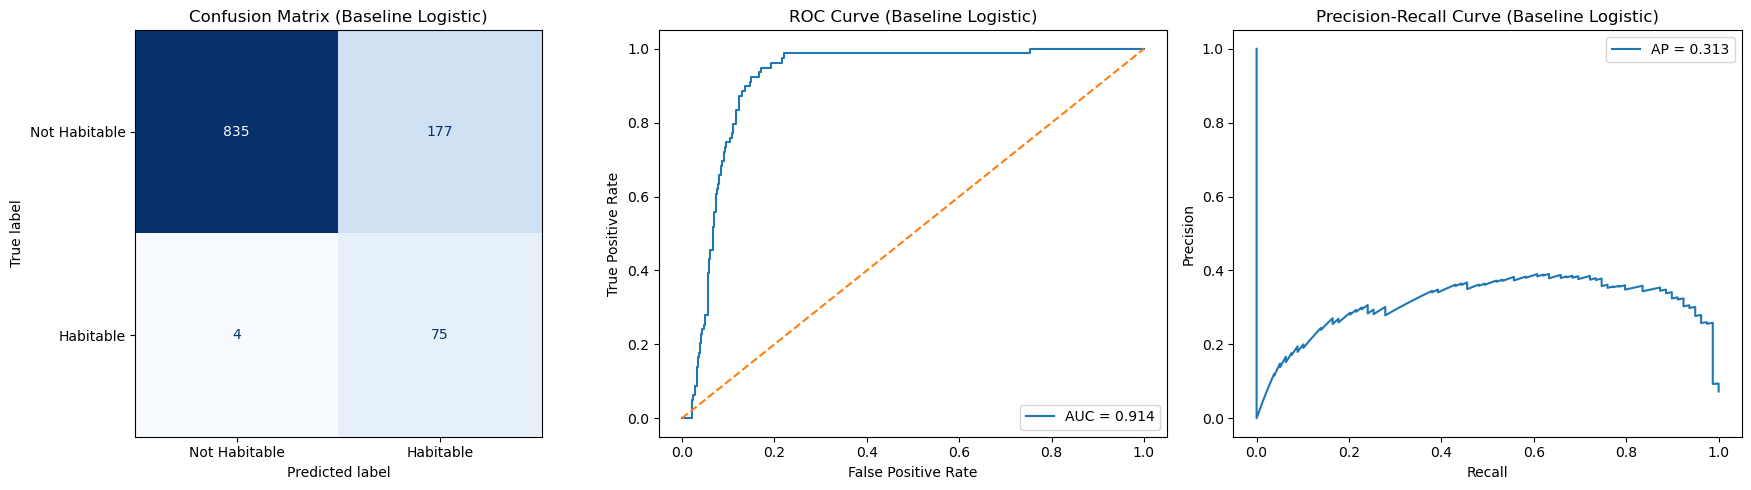

Baseline Logistic metrics at threshold = 0.500
threshold: 0.500
roc_auc: 0.9141
pr_auc: 0.3133
precision: 0.2976
recall: 0.9494
f1: 0.4532

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.83      0.90      1012
           1       0.30      0.95      0.45        79

    accuracy                           0.83      1091
   macro avg       0.65      0.89      0.68      1091
weighted avg       0.94      0.83      0.87      1091



In [74]:
baseline_metrics_05 = evaluate_probabilities(
    y_true=y_test,
    y_prob=test_prob_baseline,
    threshold=0.5,
    model_name="Baseline Logistic"
)

## 6. Hyperparameter tuning --> Model 2 L1 regularization C = 10

In [75]:
param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"]
}

tuned_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

grid = GridSearchCV(
    estimator=tuned_pipe,
    param_grid=param_grid,
    cv=5,
    scoring={
        "roc_auc": "roc_auc",
        "average_precision": "average_precision"
    },
    refit="average_precision",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV average precision:", grid.best_score_)

Best params: {'model__C': 10, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV average precision: 0.5094434273882849


In [76]:
best_model = grid.best_estimator_

val_prob_tuned = best_model.predict_proba(X_val)[:, 1]
test_prob_tuned = best_model.predict_proba(X_test)[:, 1]

### 6.1 Model 2:  Tuned Logistic regression model result on the untouched test set

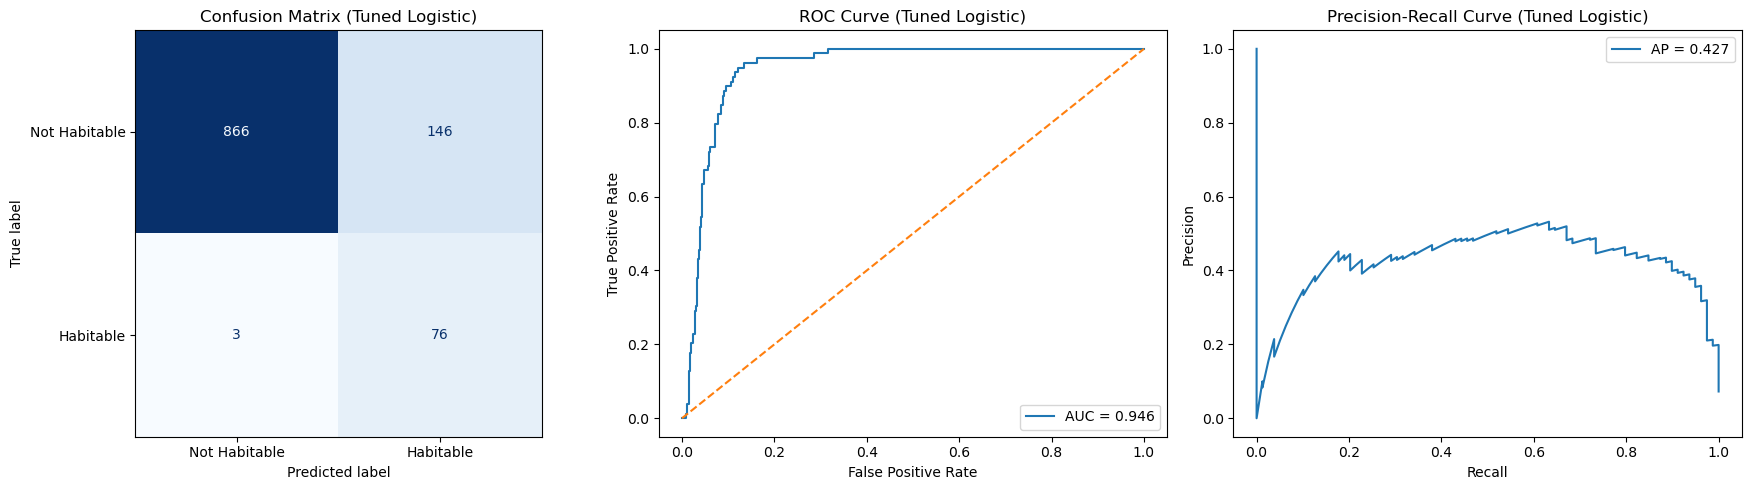

Tuned Logistic metrics at threshold = 0.500
threshold: 0.500
roc_auc: 0.9457
pr_auc: 0.4268
precision: 0.3423
recall: 0.9620
f1: 0.5050

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.86      0.92      1012
           1       0.34      0.96      0.50        79

    accuracy                           0.86      1091
   macro avg       0.67      0.91      0.71      1091
weighted avg       0.95      0.86      0.89      1091



In [77]:
tuned_metrics_05 = evaluate_probabilities(
    y_true=y_test,
    y_prob=test_prob_tuned,
    threshold=0.5,
    model_name="Tuned Logistic"
)

### 6.2 Threshold tuning on the validation set

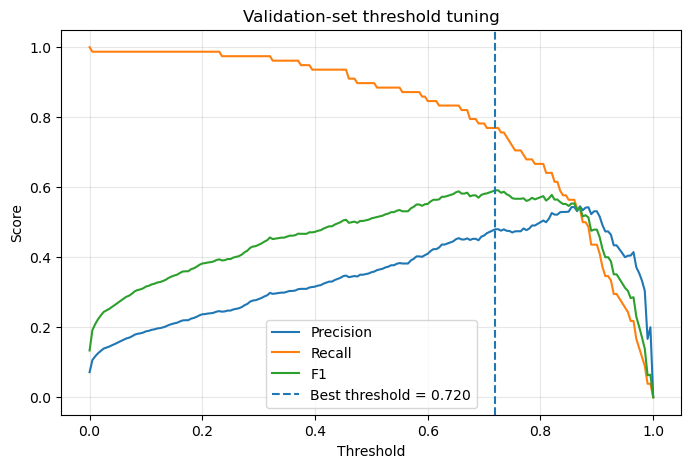

Best validation threshold: 0.72


,threshold,precision,recall,f1
144,0.720,0.480000,0.769231,0.591133
145,0.725,0.480000,0.769231,0.591133
131,0.655,0.454545,0.833333,0.588235
143,0.715,0.476190,0.769231,0.588235
147,0.735,0.479675,0.756410,0.587065


In [78]:
best_threshold, threshold_table = find_best_threshold(y_val, val_prob_tuned)
print("Best validation threshold:", round(best_threshold, 3))

threshold_table.sort_values("f1", ascending=False).head()

### 6.3 Model 3 : Tuned Logistic regression + Threshold tuning result on the untouched test set

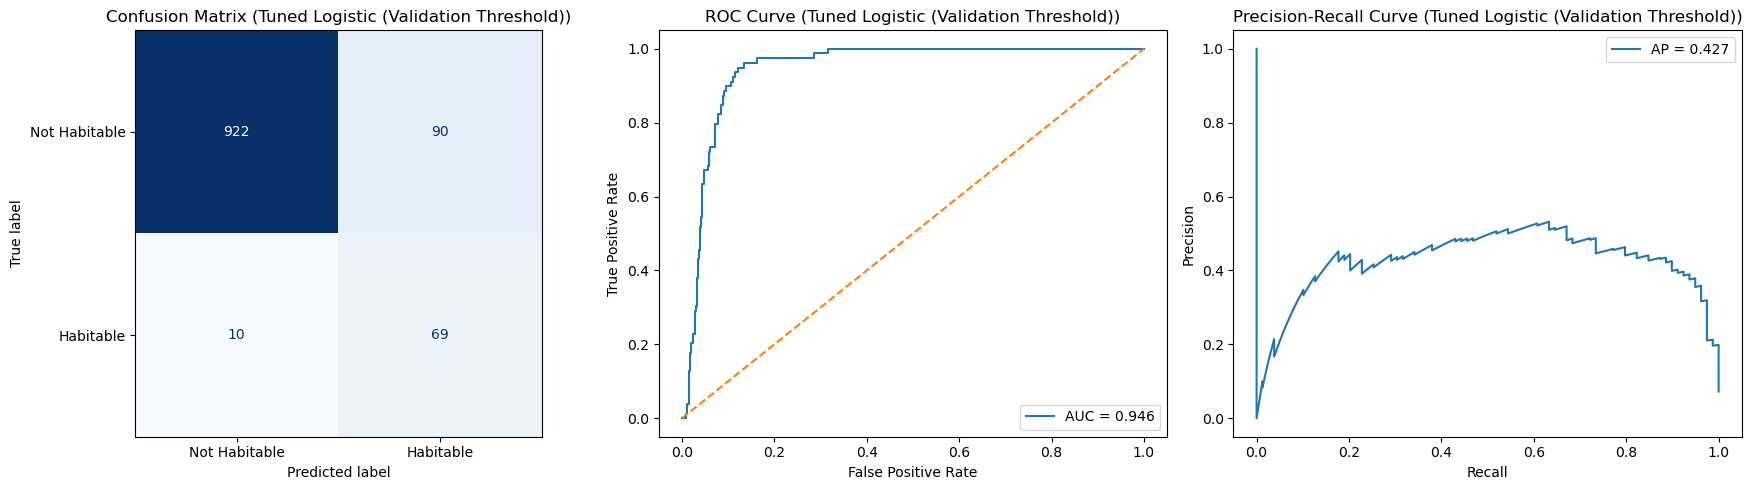

Tuned Logistic (Validation Threshold) metrics at threshold = 0.720
threshold: 0.720
roc_auc: 0.9457
pr_auc: 0.4268
precision: 0.4340
recall: 0.8734
f1: 0.5798

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.91      0.95      1012
           1       0.43      0.87      0.58        79

    accuracy                           0.91      1091
   macro avg       0.71      0.89      0.76      1091
weighted avg       0.95      0.91      0.92      1091



In [79]:
tuned_metrics_opt = evaluate_probabilities(
    y_true=y_test,
    y_prob=test_prob_tuned,
    threshold=best_threshold,
    model_name="Tuned Logistic (Validation Threshold)"
)

## 7. Coefficient inspection for the tuned logistic model(Model 3)

In [80]:
best_lr = best_model.named_steps["model"]

coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": best_lr.coef_[0]
}).sort_values("Coefficient", ascending=False)

coef_df

,Feature,Coefficient
9,log_semi_major_axis,6.071520
2,star_temp_k,1.286964
7,multi_planet_system,0.094423
5,star_metallicity,0.020352
1,orbital_period_days,0.000000
8,stellar_flux,0.000000
11,temp_distance_interaction,0.000000
6,planet_mass_earth,-0.297889
4,star_mass_sun,-0.392018
10,log_star_temp,-3.071284


## 8. SMOTE + logistic pipeline

SMOTE is applied **inside** an imbalanced-learn pipeline, so resampling happens only within the training folds during cross-validation.

In [81]:
smote_pipe = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

smote_param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"]
}

smote_grid = GridSearchCV(
    estimator=smote_pipe,
    param_grid=smote_param_grid,
    cv=5,
    scoring={
        "roc_auc": "roc_auc",
        "average_precision": "average_precision"
    },
    refit="average_precision",
    n_jobs=-1
)

smote_grid.fit(X_train, y_train)

print("Best SMOTE params:", smote_grid.best_params_)
print("Best SMOTE CV average precision:", smote_grid.best_score_)

Best SMOTE params: {'model__C': 10, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best SMOTE CV average precision: 0.5149309389493724


In [82]:
best_smote_model = smote_grid.best_estimator_

val_prob_smote = best_smote_model.predict_proba(X_val)[:, 1]
test_prob_smote = best_smote_model.predict_proba(X_test)[:, 1]

### 8.1 Model 4: Final SMOTE + default threshold of 0.5 result on the untouched test set

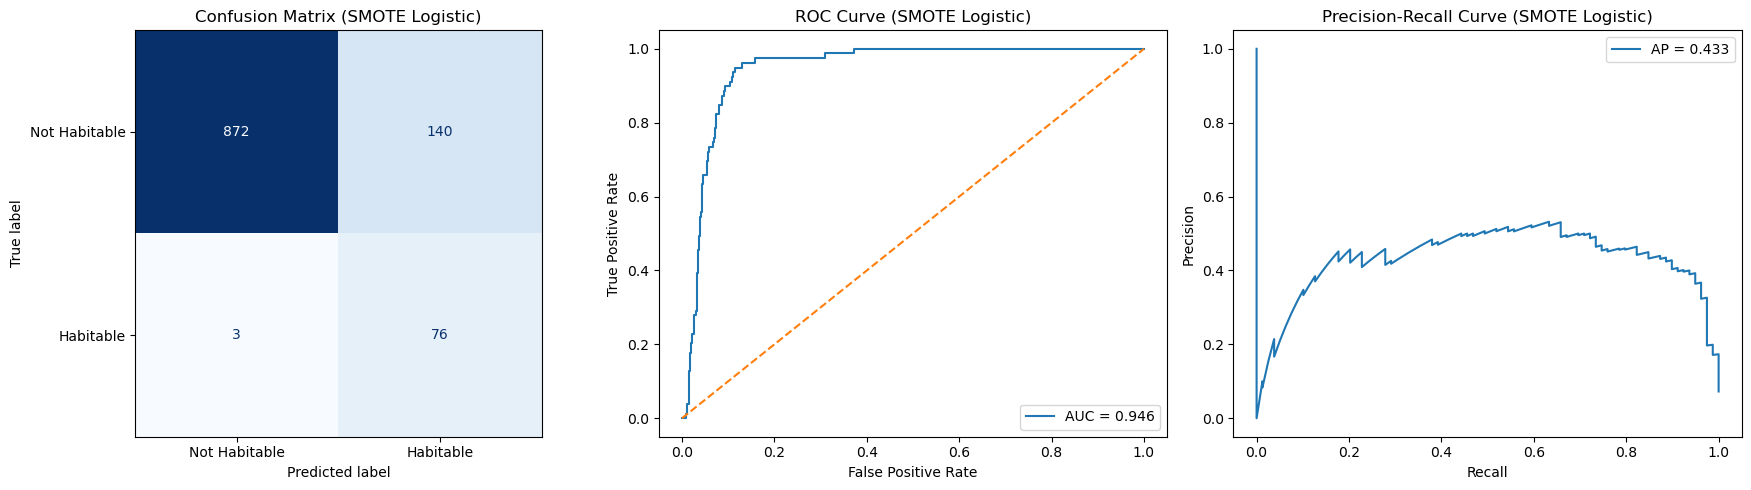

SMOTE Logistic metrics at threshold = 0.500
threshold: 0.500
roc_auc: 0.9460
pr_auc: 0.4327
precision: 0.3519
recall: 0.9620
f1: 0.5153

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.86      0.92      1012
           1       0.35      0.96      0.52        79

    accuracy                           0.87      1091
   macro avg       0.67      0.91      0.72      1091
weighted avg       0.95      0.87      0.89      1091



In [83]:
smote_metrics_05 = evaluate_probabilities(
    y_true=y_test,
    y_prob=test_prob_smote,
    threshold=0.5,
    model_name="SMOTE Logistic"
)

### 8.2 Threshold tuning for SMOTE model on validation set

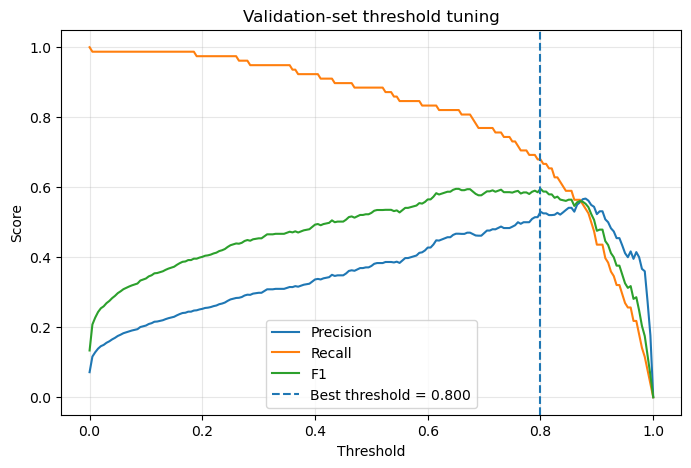

Best SMOTE validation threshold: 0.8


,threshold,precision,recall,f1
160,0.800,0.530000,0.679487,0.595506
131,0.655,0.467153,0.820513,0.595349
130,0.650,0.467153,0.820513,0.595349
135,0.675,0.470149,0.807692,0.594340
134,0.670,0.470149,0.807692,0.594340


In [84]:
best_threshold_smote, smote_threshold_table = find_best_threshold(y_val, val_prob_smote)
print("Best SMOTE validation threshold:", round(best_threshold_smote, 3))

smote_threshold_table.sort_values("f1", ascending=False).head()

### 8.3 Model 5 : Final SMOTE + Threshold tuning result on the untouched test set

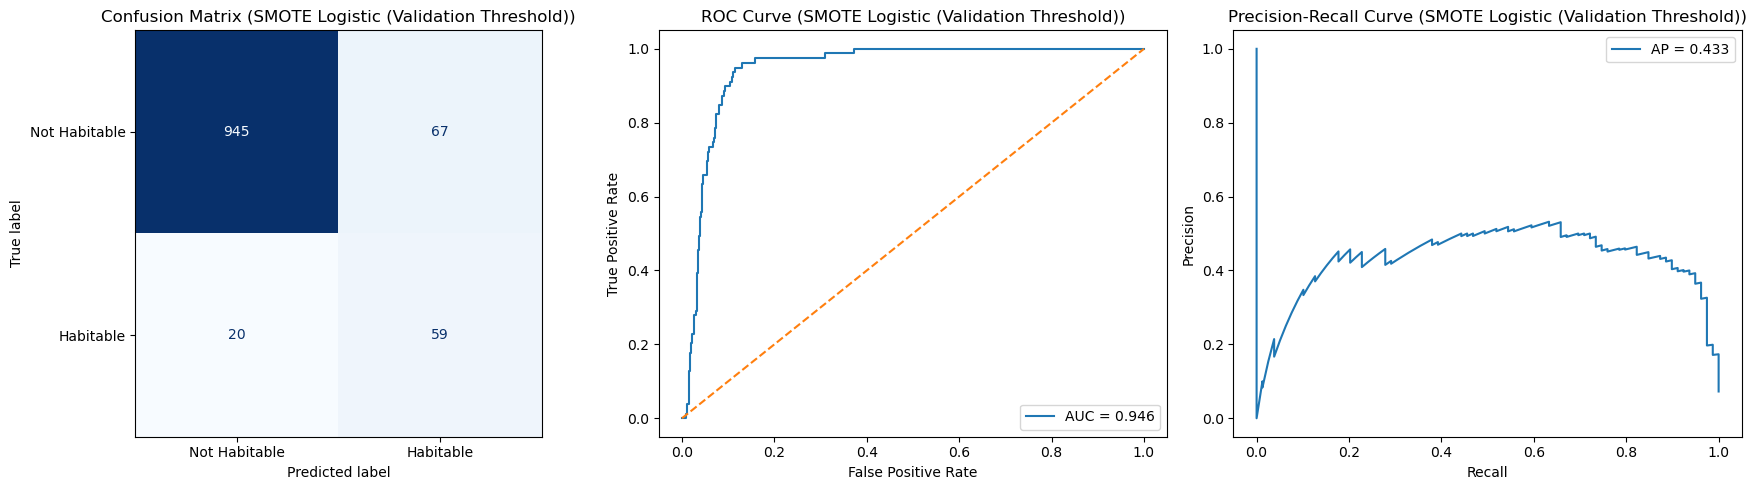

SMOTE Logistic (Validation Threshold) metrics at threshold = 0.800
threshold: 0.800
roc_auc: 0.9460
pr_auc: 0.4327
precision: 0.4683
recall: 0.7468
f1: 0.5756

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.96      1012
           1       0.47      0.75      0.58        79

    accuracy                           0.92      1091
   macro avg       0.72      0.84      0.77      1091
weighted avg       0.94      0.92      0.93      1091



In [85]:
smote_metrics_opt = evaluate_probabilities(
    y_true=y_test,
    y_prob=test_prob_smote,
    threshold=best_threshold_smote,
    model_name="SMOTE Logistic (Validation Threshold)"
)

## 9. Final comparison table

In [86]:
results = pd.DataFrame([
    {"model": "Baseline Logistic @0.5", **baseline_metrics_05},
    {"model": "Tuned Logistic @0.5", **tuned_metrics_05},
    {"model": "Tuned Logistic @val threshold", **tuned_metrics_opt},
    {"model": "SMOTE Logistic @0.5", **smote_metrics_05},
    {"model": "SMOTE Logistic @val threshold", **smote_metrics_opt},
])

results.sort_values(["pr_auc", "f1"], ascending=False)

,model,threshold,roc_auc,pr_auc,precision,recall,f1
4,SMOTE Logistic @val threshold,0.80,0.946015,0.432688,0.468254,0.746835,0.575610
3,SMOTE Logistic @0.5,0.50,0.946015,0.432688,0.351852,0.962025,0.515254
2,Tuned Logistic @val threshold,0.72,0.945740,0.426827,0.433962,0.873418,0.579832
1,Tuned Logistic @0.5,0.50,0.945740,0.426827,0.342342,0.962025,0.504983
0,Baseline Logistic @0.5,0.50,0.914069,0.313286,0.297619,0.949367,0.453172
